# RECURRENT NEURAL NETWORK (RNN) FOR TEXT GENERATION
 Rithish A 24BAD099

In [30]:
from datasets import load_dataset

dataset = load_dataset("Trelis/tiny-shakespeare")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})


In [31]:
print(dataset["train"][0])

{'Text': "First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good.\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance is a gain to them Let us revenge this with\nour pikes, ere we become rakes: for the gods know I\nspeak this i

In [32]:
for i in range(3):
    print(f"\n--- Sample {i+1} ---")
    print(dataset["train"][i]["Text"][:1000])


--- Sample 1 ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thi

In [33]:
# Combine all training text
text = "\n".join(dataset["train"]["Text"])

print("Total characters:", len(text))
print("\nFirst 1000 characters:\n")
print(text[:1000])

Total characters: 1222825

First 1000 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak thi

In [34]:
# Convert text to lowercase
text = text.lower()

print("First 500 characters after lowercasing:\n")
print(text[:500])

First 500 characters after lowercasing:

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [35]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Create word-level tokenizer
tokenizer = Tokenizer(
    oov_token="<OOV>"
)

# Fit tokenizer on the text
tokenizer.fit_on_texts([text])

# Convert text into integer sequences
total_sequence = tokenizer.texts_to_sequences([text])[0]

print("Total tokens:", len(total_sequence))
print("First 30 token IDs:")
print(total_sequence[:30])

Total tokens: 223886
First 30 token IDs:
[80, 261, 150, 35, 876, 149, 651, 128, 16, 107, 36, 107, 107, 80, 261, 8, 42, 36, 1383, 348, 4, 193, 66, 4, 4237, 36, 1383, 1383, 80, 261]


In [36]:
# Vocabulary
word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))

print("\nFirst 20 words in vocabulary:")
for word, index in list(word_index.items())[:20]:
    print(word, ":", index)

Vocabulary size: 11980

First 20 words in vocabulary:
<OOV> : 1
the : 2
and : 3
to : 4
i : 5
of : 6
my : 7
you : 8
a : 9
that : 10
in : 11
is : 12
not : 13
for : 14
with : 15
me : 16
it : 17
your : 18
be : 19
his : 20


In [37]:
# Reverse mapping: integer -> word
index_word = tokenizer.index_word

print("First 20 tokens converted back to words:\n")

for token_id in total_sequence[:20]:
    print(token_id, "->", index_word[token_id])

First 20 tokens converted back to words:

80 -> first
261 -> citizen
150 -> before
35 -> we
876 -> proceed
149 -> any
651 -> further
128 -> hear
16 -> me
107 -> speak
36 -> all
107 -> speak
107 -> speak
80 -> first
261 -> citizen
8 -> you
42 -> are
36 -> all
1383 -> resolved
348 -> rather


In [38]:
import numpy as np

# Maximum sequence length
MAX_SEQUENCE_LENGTH = 20

input_sequences = []

# Create sequences using a sliding window
for i in range(MAX_SEQUENCE_LENGTH, len(total_sequence)):
    sequence = total_sequence[i - MAX_SEQUENCE_LENGTH:i + 1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

print("Shape of generated sequences:", input_sequences.shape)
print("First sequence:")
print(input_sequences[0])

Shape of generated sequences: (223866, 21)
First sequence:
[  80  261  150   35  876  149  651  128   16  107   36  107  107   80
  261    8   42   36 1383  348    4]


In [39]:
# Input words
X = input_sequences[:, :-1]

# Target word
y = input_sequences[:, -1]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (223866, 20)
Target shape: (223866,)


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 179092
Validation samples: 44774


In [41]:
print("\nDataset Preparation Summary")
print("---------------------------")
print("Vocabulary Size :", len(word_index))
print("Sequence Length  :", X.shape[1])
print("Training Samples :", X_train.shape[0])
print("Validation Samples:", X_val.shape[0])


Dataset Preparation Summary
---------------------------
Vocabulary Size : 11980
Sequence Length  : 20
Training Samples : 179092
Validation Samples: 44774


In [42]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pad sequences to a fixed length
X_padded = pad_sequences(
    X,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="pre"
)

print("Padded input shape:", X_padded.shape)

Padded input shape: (223866, 20)


In [43]:
#Split after padding
X_train, X_val, y_train, y_val = train_test_split(
    X_padded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training input shape:", X_train.shape)
print("Validation input shape:", X_val.shape)

Training input shape: (179092, 20)
Validation input shape: (44774, 20)


In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("TensorFlow version:", tf.__version__)
#Define model parameters
VOCAB_SIZE = len(tokenizer.word_index) + 1
EMBEDDING_DIM = 128
RNN_UNITS = 128

print("Vocabulary Size:", VOCAB_SIZE)
print("Embedding Dimension:", EMBEDDING_DIM)
print("RNN Units:", RNN_UNITS)

TensorFlow version: 2.20.0
Vocabulary Size: 11981
Embedding Dimension: 128
RNN Units: 128


In [45]:
model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH
    ),

    SimpleRNN(
        RNN_UNITS
    ),

    Dense(
        VOCAB_SIZE,
        activation="softmax"
    )
])

model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │     1,533,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11981)          │     1,545,549 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,112,013 (11.87 MB)

 Trainable params: 3,112,013 (11.87 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [47]:
model_adam = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    SimpleRNN(RNN_UNITS),
    Dense(VOCAB_SIZE, activation="softmax")
])

model_adam.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_adam.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
EPOCHS = 10
BATCH_SIZE = 128

history_adam = model_adam.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 104s 74ms/step - accuracy: 0.0507 - loss: 6.6646 - val_accuracy: 0.0758 - val_loss: 6.2730
Epoch 2/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 145s 76ms/step - accuracy: 0.0888 - loss: 5.9842 - val_accuracy: 0.0907 - val_loss: 6.0599
Epoch 3/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 106s 76ms/step - accuracy: 0.1079 - loss: 5.5867 - val_accuracy: 0.0961 - val_loss: 5.9878
Epoch 4/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 142s 75ms/step - accuracy: 0.1259 - loss: 5.2439 - val_accuracy: 0.1016 - val_loss: 5.9646
Epoch 5/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 138s 73ms/step - accuracy: 0.1484 - loss: 4.9318 - val_accuracy: 0.1034 - val_loss: 5.9669
Epoch 6/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 142s 73ms/step - accuracy: 0.1746 - loss: 4.6393 - val_accuracy: 0.1080 - val_loss: 5.9930
Epoch 7/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 104s 75ms/step - accuracy: 0.2069 - loss: 4.3660 - val_accuracy: 0.1132 - val_loss: 6.0182
Epoch 8/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 148s 79ms/step - accuracy: 

In [49]:
model_rmsprop = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    SimpleRNN(RNN_UNITS),
    Dense(VOCAB_SIZE, activation="softmax")
])

model_rmsprop.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_rmsprop.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
history_rmsprop = model_rmsprop.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 111s 79ms/step - accuracy: 0.0307 - loss: 6.9487 - val_accuracy: 0.0395 - val_loss: 6.7531
Epoch 2/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 120s 86ms/step - accuracy: 0.0533 - loss: 6.6091 - val_accuracy: 0.0631 - val_loss: 6.5054
Epoch 3/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 106s 76ms/step - accuracy: 0.0740 - loss: 6.4091 - val_accuracy: 0.0723 - val_loss: 6.3669
Epoch 4/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 148s 80ms/step - accuracy: 0.0849 - loss: 6.2920 - val_accuracy: 0.0835 - val_loss: 6.2780
Epoch 5/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 108s 77ms/step - accuracy: 0.0912 - loss: 6.1813 - val_accuracy: 0.0853 - val_loss: 6.2269
Epoch 6/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 144s 79ms/step - accuracy: 0.0979 - loss: 6.0985 - val_accuracy: 0.0891 - val_loss: 6.1814
Epoch 7/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 141s 101ms/step - accuracy: 0.1028 - loss: 6.0205 - val_accuracy: 0.0900 - val_loss: 6.1579
Epoch 8/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 135s 96ms/step - accuracy:

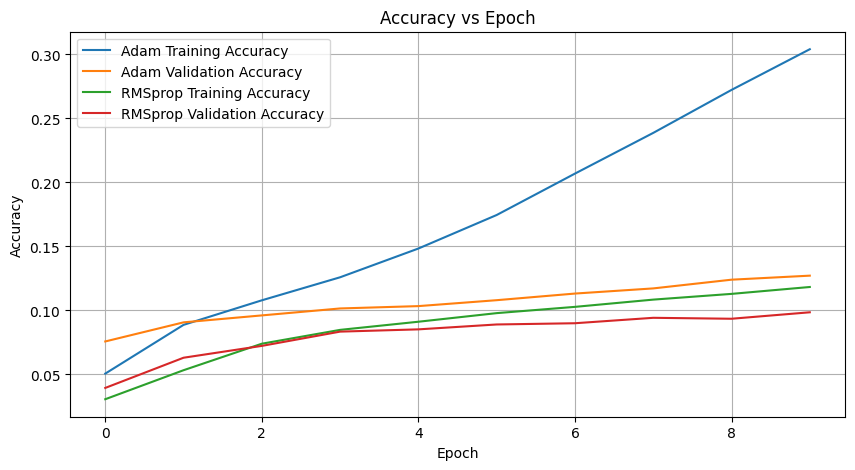

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history_adam.history["accuracy"],
    label="Adam Training Accuracy"
)

plt.plot(
    history_adam.history["val_accuracy"],
    label="Adam Validation Accuracy"
)

plt.plot(
    history_rmsprop.history["accuracy"],
    label="RMSprop Training Accuracy"
)

plt.plot(
    history_rmsprop.history["val_accuracy"],
    label="RMSprop Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

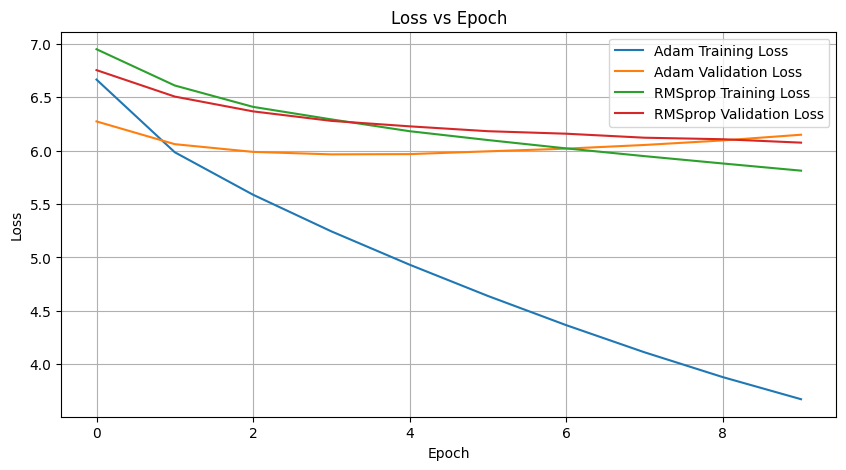

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_adam.history["loss"],
    label="Adam Training Loss"
)

plt.plot(
    history_adam.history["val_loss"],
    label="Adam Validation Loss"
)

plt.plot(
    history_rmsprop.history["loss"],
    label="RMSprop Training Loss"
)

plt.plot(
    history_rmsprop.history["val_loss"],
    label="RMSprop Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
print("ADAM RESULTS")
print("---------------------------")
print("Training Accuracy  :", history_adam.history["accuracy"][-1])
print("Validation Accuracy:", history_adam.history["val_accuracy"][-1])
print("Training Loss      :", history_adam.history["loss"][-1])
print("Validation Loss    :", history_adam.history["val_loss"][-1])

print("\nRMSPROP RESULTS")
print("---------------------------")
print("Training Accuracy  :", history_rmsprop.history["accuracy"][-1])
print("Validation Accuracy:", history_rmsprop.history["val_accuracy"][-1])
print("Training Loss      :", history_rmsprop.history["loss"][-1])
print("Validation Loss    :", history_rmsprop.history["val_loss"][-1])

ADAM RESULTS
---------------------------
Training Accuracy  : 0.30403926968574524
Validation Accuracy: 0.1271943598985672
Training Loss      : 3.6727473735809326
Validation Loss    : 6.148326396942139

RMSPROP RESULTS
---------------------------
Training Accuracy  : 0.11834140866994858
Validation Accuracy: 0.09858399629592896
Training Loss      : 5.812040328979492
Validation Loss    : 6.074270248413086


In [55]:
# Use the Adam model for text generation
text_model = model_adam

print("Adam model selected for text generation.")

Adam model selected for text generation.


In [56]:
def generate_text(seed_text, next_words=20):

    for _ in range(next_words):

        # Convert seed text into word IDs
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        # Keep only the latest words
        token_list = token_list[-MAX_SEQUENCE_LENGTH:]

        # Pad the sequence
        token_list = pad_sequences(
            [token_list],
            maxlen=MAX_SEQUENCE_LENGTH,
            padding="pre"
        )

        # Predict next word
        predicted_probabilities = text_model.predict(
            token_list,
            verbose=0
        )

        predicted_word_id = np.argmax(predicted_probabilities, axis=-1)[0]

        # Convert ID back to word
        predicted_word = tokenizer.index_word.get(
            predicted_word_id,
            ""
        )

        if predicted_word == "":
            break

        # Add predicted word to the sequence
        seed_text += " " + predicted_word

    return seed_text

In [57]:
seed_text = "to be or not to be"

generated_text = generate_text(
    seed_text,
    next_words=30
)

print("Generated Text:")
print(generated_text)

Generated Text:
to be or not to be seen in the prison hoping thou wilt be patient wrong that if i had rather be a roman of your own affections and not your loves i know not what


In [58]:
seed_inputs = [
    "to be or not to be",
    "the king",
    "my lord",
    "what is"
]

for seed in seed_inputs:

    print("\n" + "=" * 60)
    print("Seed:", seed)
    print("=" * 60)

    generated = generate_text(
        seed,
        next_words=25
    )

    print(generated)


Seed: to be or not to be
to be or not to be seen in the prison hoping thou wilt be patient wrong that if i had rather be a roman of your own affections and not your

Seed: the king
the king and bashful henry bolingbroke o lancaster and leave me to the king and signify to me and so i am in tiber i am i

Seed: my lord
my lord king richard iii o let me be thy mother and therefore be good for ever i am sorry for the man i have my lord

Seed: what is
what is thy mother clarence to make thee thou art thou art thy wife is thy mother for a poor soul of thine own blood which is


In [59]:
def generate_with_model(model, seed_text, next_words=20):

    generated_text = seed_text

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]

        token_list = token_list[-MAX_SEQUENCE_LENGTH:]

        token_list = pad_sequences(
            [token_list],
            maxlen=MAX_SEQUENCE_LENGTH,
            padding="pre"
        )

        predictions = model.predict(
            token_list,
            verbose=0
        )

        predicted_id = np.argmax(predictions, axis=-1)[0]

        predicted_word = tokenizer.index_word.get(
            predicted_id,
            ""
        )

        if predicted_word == "":
            break

        generated_text += " " + predicted_word

    return generated_text


In [60]:
seed = "the king"

print("ADAM GENERATED TEXT")
print("---------------------------")
print(
    generate_with_model(
        model_adam,
        seed,
        25
    )
)

print("\nRMSPROP GENERATED TEXT")
print("---------------------------")
print(
    generate_with_model(
        model_rmsprop,
        seed,
        25
    )
)

ADAM GENERATED TEXT
---------------------------
the king and bashful henry bolingbroke o lancaster and leave me to the king and signify to me and so i am in tiber i am i

RMSPROP GENERATED TEXT
---------------------------
the king and not the king and not the king and not the king and not the king and not the king and not the king and
